# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [19]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [20]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.bias = None
        # Xavier uniform initialization
        nn.init.xavier_uniform_(self.weight)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        z = x @ self.weight.T
        if self.bias is not None:
            z = z + self.bias
        return z

In [21]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(num_embeddings, embedding_dim))

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [22]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if not self.training or self.p == 0.0:
            return x
        mask = (torch.rand_like(x) > self.p).float()
        return x * mask / (1.0 - self.p)

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [23]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return x_norm * self.weight + self.bias

In [24]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        rms = torch.sqrt(torch.mean(x * x, dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [25]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        layers = []
        if depth == 1:
            layers.append(Linear(in_dim, out_dim))
        else:
            # First layer: in_dim -> hidden_dim
            layers.append(Linear(in_dim, hidden_dim))
            if use_layernorm:
                layers.append(LayerNorm(hidden_dim))
            layers.append(nn.GELU())

            # Middle layers: hidden_dim -> hidden_dim
            for _ in range(depth - 2):
                layers.append(Linear(hidden_dim, hidden_dim))
                if use_layernorm:
                    layers.append(LayerNorm(hidden_dim))
                layers.append(nn.GELU())

            # Last layer: hidden_dim -> out_dim
            layers.append(Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [26]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.w1 = Linear(d_model, d_ff)
        self.act = nn.GELU()
        self.w2 = Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.w2(self.act(self.w1(x)))

In [27]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [28]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [29]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [30]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    # Stable log-softmax: subtract max for numerical stability
    max_logits = logits.max(dim=-1, keepdim=True).values
    shifted = logits - max_logits
    log_probs = shifted - shifted.exp().sum(dim=-1, keepdim=True).log()

    # Pick the log-prob of the correct class for each sample
    B = logits.shape[0]
    loss = -log_probs[torch.arange(B), targets].mean()
    return loss

In [31]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.linear = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.linear(x)

In [32]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            x = images.view(images.shape[0], -1)  # flatten to (B, 784)
            logits = model(x)
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.shape[0]
    return correct / total

In [33]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> tuple[list[float], list[float]]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step) and test losses (one per epoch)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        for images, labels in train_data_loader:
            x = images.view(images.shape[0], -1)  # flatten to (B, 784)
            logits = model(x)
            loss = cross_entropy_from_logits(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # Evaluate at end of epoch: compute test loss and accuracy
        model.eval()
        test_loss_sum = 0.0
        test_batches = 0
        with torch.no_grad():
            for images, labels in test_data_loader:
                x = images.view(images.shape[0], -1)
                logits = model(x)
                test_loss_sum += cross_entropy_from_logits(logits, labels).item()
                test_batches += 1
        test_losses.append(test_loss_sum / test_batches)

        acc = accuracy(model, test_data_loader)
        print(f"Epoch {epoch+1}/{epochs} - Test loss: {test_losses[-1]:.4f}, Test accuracy: {acc:.4f}")

    return train_losses, test_losses

Epoch 1/5 - Test loss: 0.1100, Test accuracy: 0.9656
Epoch 2/5 - Test loss: 0.0764, Test accuracy: 0.9766
Epoch 3/5 - Test loss: 0.0685, Test accuracy: 0.9778
Epoch 4/5 - Test loss: 0.0699, Test accuracy: 0.9777
Epoch 5/5 - Test loss: 0.0677, Test accuracy: 0.9809


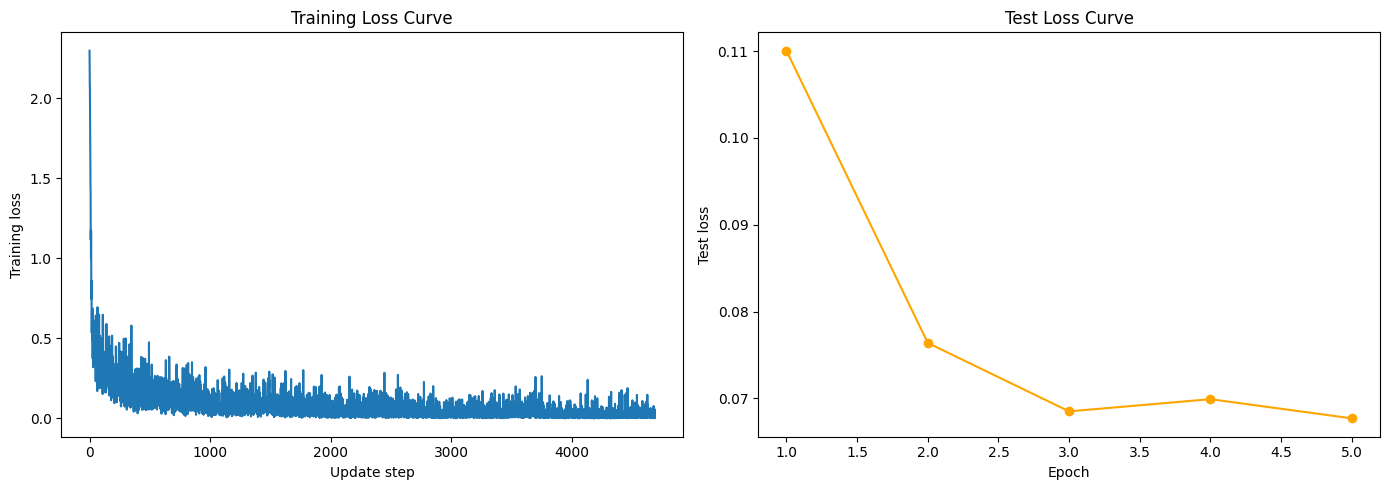

Final test accuracy: 0.9809


In [34]:
import matplotlib.pyplot as plt

# Build classifier: flatten -> MLP(784, 256, 10, depth=3)
model = nn.Sequential(
    nn.Flatten(),
    MLP(in_dim=784, hidden_dim=256, out_dim=10, depth=3),
)

# Train for 5 epochs
train_losses, test_losses = train_classifier(model, train_loader, test_loader, lr=1e-3, epochs=5)

# Plot training loss curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses)
ax1.set_xlabel("Update step")
ax1.set_ylabel("Training loss")
ax1.set_title("Training Loss Curve")

# Plot test loss curve (one point per epoch)
steps_per_epoch = len(train_losses) // len(test_losses)
epoch_steps = [(i + 1) * steps_per_epoch for i in range(len(test_losses))]
ax2.plot(range(1, len(test_losses) + 1), test_losses, marker='o', color='orange')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Test loss")
ax2.set_title("Test Loss Curve")

plt.tight_layout()
plt.show()

# Final accuracy
final_acc = accuracy(model, test_loader)
print(f"Final test accuracy: {final_acc:.4f}")

## Sanity Checks & Tests
Compare our implementations against PyTorch reference modules.

In [35]:
# --- Test 1: Basic Layers ---
print("=== Test Linear ===")
torch.manual_seed(42)
my_lin = Linear(8, 4)
ref_lin = nn.Linear(8, 4)
# Copy our weights into the reference
ref_lin.weight = nn.Parameter(my_lin.weight.data.clone())
ref_lin.bias = nn.Parameter(my_lin.bias.data.clone())
x = torch.randn(3, 8)
my_out = my_lin(x)
ref_out = ref_lin(x)
assert torch.allclose(my_out, ref_out, atol=1e-6), "Linear output mismatch!"
print(f"  Output shape: {my_out.shape}")  # (3, 4)
# Test with leading batch dims
x_batch = torch.randn(2, 3, 8)
assert my_lin(x_batch).shape == (2, 3, 4), "Linear batch dims failed!"
# Test without bias
my_lin_nb = Linear(8, 4, bias=False)
assert my_lin_nb.bias is None, "Linear(bias=False) should have no bias!"
print("  Linear: PASSED")

print("\n=== Test Embedding ===")
torch.manual_seed(42)
my_emb = Embedding(10, 16)
ref_emb = nn.Embedding(10, 16)
ref_emb.weight = nn.Parameter(my_emb.weight.data.clone())
idx = torch.tensor([0, 3, 7, 3])
my_out = my_emb(idx)
ref_out = ref_emb(idx)
assert torch.allclose(my_out, ref_out, atol=1e-6), "Embedding output mismatch!"
assert my_out.shape == (4, 16), f"Embedding shape wrong: {my_out.shape}"
# Test batch dims
idx_batch = torch.tensor([[0, 1], [2, 3]])
assert my_emb(idx_batch).shape == (2, 2, 16), "Embedding batch dims failed!"
print(f"  Output shape: {my_out.shape}")
print("  Embedding: PASSED")

print("\n=== Test Dropout ===")
drop = Dropout(p=0.5)
x = torch.ones(1000)
# Train mode: some values should be zero, others scaled by 2
drop.train()
out_train = drop(x)
num_zeros = (out_train == 0).sum().item()
assert num_zeros > 0, "Dropout should zero some values in train mode!"
assert torch.allclose(out_train.mean(), torch.tensor(1.0), atol=0.15), \
    f"Dropout expected mean ~1.0, got {out_train.mean():.3f}"
# Eval mode: should pass through unchanged
drop.eval()
out_eval = drop(x)
assert torch.allclose(out_eval, x), "Dropout should pass through in eval mode!"
print("  Dropout: PASSED")

print("\nAll basic layer tests passed!")

=== Test Linear ===
  Output shape: torch.Size([3, 4])
  Linear: PASSED

=== Test Embedding ===
  Output shape: torch.Size([4, 16])
  Embedding: PASSED

=== Test Dropout ===
  Dropout: PASSED

All basic layer tests passed!


In [36]:
# --- Test 2: Normalization ---
print("=== Test LayerNorm ===")
torch.manual_seed(42)
D = 16
my_ln = LayerNorm(D)
ref_ln = nn.LayerNorm(D)
# Copy weights
ref_ln.weight = nn.Parameter(my_ln.weight.data.clone())
ref_ln.bias = nn.Parameter(my_ln.bias.data.clone())
x = torch.randn(4, D)
my_out = my_ln(x)
ref_out = ref_ln(x)
assert torch.allclose(my_out, ref_out, atol=1e-5), \
    f"LayerNorm mismatch! Max diff: {(my_out - ref_out).abs().max():.2e}"
print(f"  Output shape: {my_out.shape}")
# Verify normalized stats: mean ~0, std ~1 (before affine)
x_normed = (x - x.mean(-1, keepdim=True)) / torch.sqrt(x.var(-1, keepdim=True, unbiased=False) + 1e-5)
assert torch.allclose(x_normed.mean(-1), torch.zeros(4), atol=1e-5), "LayerNorm mean not ~0!"
print("  LayerNorm: PASSED")

print("\n=== Test RMSNorm ===")
torch.manual_seed(42)
my_rms = RMSNorm(D)
x = torch.randn(4, D)
my_out = my_rms(x)
# Manual computation for reference
rms = torch.sqrt(torch.mean(x * x, dim=-1, keepdim=True) + 1e-8)
expected = x / rms * my_rms.weight
assert torch.allclose(my_out, expected, atol=1e-6), "RMSNorm mismatch!"
assert my_out.shape == (4, D), f"RMSNorm shape wrong: {my_out.shape}"
print(f"  Output shape: {my_out.shape}")
print("  RMSNorm: PASSED")

print("\nAll normalization tests passed!")

=== Test LayerNorm ===
  Output shape: torch.Size([4, 16])
  LayerNorm: PASSED

=== Test RMSNorm ===
  Output shape: torch.Size([4, 16])
  RMSNorm: PASSED

All normalization tests passed!


In [37]:
# --- Test 3: MLPs and Residual ---
print("=== Test MLP ===")
torch.manual_seed(42)
mlp = MLP(in_dim=8, hidden_dim=16, out_dim=4, depth=3)
x = torch.randn(5, 8)
out = mlp(x)
assert out.shape == (5, 4), f"MLP output shape wrong: {out.shape}"
# Test depth=1 (single layer, no hidden)
mlp1 = MLP(in_dim=8, hidden_dim=16, out_dim=4, depth=1)
assert mlp1(x).shape == (5, 4), "MLP depth=1 failed!"
# Test with LayerNorm
mlp_ln = MLP(in_dim=8, hidden_dim=16, out_dim=4, depth=3, use_layernorm=True)
assert mlp_ln(x).shape == (5, 4), "MLP with LayerNorm failed!"
print(f"  Output shape: {out.shape}")
print("  MLP: PASSED")

print("\n=== Test FeedForward ===")
torch.manual_seed(42)
ff = FeedForward(d_model=32)
x = torch.randn(2, 10, 32)
out = ff(x)
assert out.shape == (2, 10, 32), f"FeedForward shape wrong: {out.shape}"
# Check internal expansion: w1 should map 32 -> 128
assert ff.w1.weight.shape == (128, 32), "FeedForward expansion wrong!"
# Test custom d_ff
ff2 = FeedForward(d_model=32, d_ff=64)
assert ff2.w1.weight.shape == (64, 32), "FeedForward custom d_ff wrong!"
print(f"  Output shape: {out.shape}")
print("  FeedForward: PASSED")

print("\n=== Test Residual ===")
torch.manual_seed(42)
ff = FeedForward(d_model=16)
res = Residual(ff)
x = torch.randn(3, 16)
out = res(x)
expected = x + ff(x)
assert torch.allclose(out, expected, atol=1e-6), "Residual output mismatch!"
assert out.shape == x.shape, f"Residual shape wrong: {out.shape}"
print(f"  Output shape: {out.shape}")
print("  Residual: PASSED")

print("\nAll MLP/Residual tests passed!")

=== Test MLP ===
  Output shape: torch.Size([5, 4])
  MLP: PASSED

=== Test FeedForward ===
  Output shape: torch.Size([2, 10, 32])
  FeedForward: PASSED

=== Test Residual ===
  Output shape: torch.Size([3, 16])
  Residual: PASSED

All MLP/Residual tests passed!


In [38]:
# --- Test 4: Classification ---
import torch.nn.functional as F

print("=== Test cross_entropy_from_logits ===")
torch.manual_seed(42)
logits = torch.randn(8, 5)
targets = torch.randint(0, 5, (8,))
my_loss = cross_entropy_from_logits(logits, targets)
ref_loss = F.cross_entropy(logits, targets)
assert torch.allclose(my_loss, ref_loss, atol=1e-5), \
    f"cross_entropy mismatch! Ours: {my_loss:.6f}, Ref: {ref_loss:.6f}"
print(f"  Our loss: {my_loss:.6f}, PyTorch ref: {ref_loss:.6f}")
# Test with large logits (stability check)
big_logits = torch.tensor([[1000.0, 0.0, 0.0], [0.0, 1000.0, 0.0]])
big_targets = torch.tensor([0, 1])
big_loss = cross_entropy_from_logits(big_logits, big_targets)
assert not torch.isnan(big_loss) and not torch.isinf(big_loss), "cross_entropy not stable with large logits!"
print(f"  Stability test (large logits): loss = {big_loss:.6f}")
print("  cross_entropy_from_logits: PASSED")

print("\n=== Test ClassificationHead ===")
head = ClassificationHead(d_in=32, num_classes=10)
x = torch.randn(4, 32)
out = head(x)
assert out.shape == (4, 10), f"ClassificationHead shape wrong: {out.shape}"
print(f"  Output shape: {out.shape}")
print("  ClassificationHead: PASSED")

print("\nAll classification tests passed!")

=== Test cross_entropy_from_logits ===
  Our loss: 1.508245, PyTorch ref: 1.508245
  Stability test (large logits): loss = -0.000000
  cross_entropy_from_logits: PASSED

=== Test ClassificationHead ===
  Output shape: torch.Size([4, 10])
  ClassificationHead: PASSED

All classification tests passed!
